# 🧹 Preprocessing — Explained

**📖 The Story So Far.** A model is only as fair as the numbers we hand it. Today: three columns of sensor-like data (`A`, `B`, `C`) that live at wildly different scales, plus categorical labels, imbalanced classes, missing values, and dates. Raw, all of this would confuse any algorithm. Our job: clean, rescale, and encode — without lying to the model.

**🗺️ The Journey**
1. ⚙️ Setup
2. 📊 The data + why raw scales are a problem
3. 📏 Scaling — `StandardScaler`, `MinMaxScaler`, `RobustScaler`
4. 🔲 `Binarizer` — threshold to 0/1
5. 📐 `Normalizer` — scaling rows instead of columns
6. 🏷️ Encoders — `LabelEncoder`, `OneHotEncoder`, `OrdinalEncoder`
7. ⚖️ Class imbalance — over/under-sampling
8. 🕳️ Missing values — imputation vs deletion
9. 🛠️ Feature engineering — log, interaction, binning, dates

## ⚙️ Setup

**What:** one import line pulling in every tool we use today.
**Why here:** nothing runs without it; each import earns its place below.
**What breaks if skipped:** every cell after this throws `NameError`.

- `numpy` — fast array math; the scaler outputs are `ndarray`, not DataFrames.
- `pandas` — the DataFrame wrapper so columns keep names and we can plot.
- `matplotlib.pyplot` — the plotting engine behind `df.plot.kde()`.
- `sklearn.preprocessing` — the seven transformers this notebook demos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler,Binarizer,Normalizer,OneHotEncoder,LabelEncoder

## 📊 The Data — three columns that can't see each other

**What:** generate 10,000 rows × 3 columns, each from a different normal distribution.
**Why here:** we need data where the *scale problem* is visible before we can feel why scaling exists.
**What breaks if skipped:** every later cell operates on `df` — no data, no demo.

- `A ~ N(mean=0, std=2)` — centred near 0, narrow.
- `B ~ N(mean=5, std=3)` — shifted up, wider.
- `C ~ N(mean=-5, std=5)` — shifted down, widest.

Backend analogy: three services reporting latency — one in **ms**, one in **µs**, one in **seconds**. Same quantity, incomparable numbers.

In [2]:
np.random.seed(5)
a = np.random.normal(0, 2, 10000)
b = np.random.normal(5, 3, 10000)
c = np.random.normal(-5, 5, 10000)

df = pd.DataFrame({
    'A' : a,
    'B' : b,
    'C' : c
})
df

,A,B,C
0,0.882455,1.466990,-7.089363
1,-0.661740,0.571914,-3.105893
2,4.861542,7.828852,-1.039068
3,-0.504184,5.001904,-9.755722
4,0.219220,1.731128,-7.679528
...,...,...,...
9995,-0.068972,3.739968,-4.303864
9996,-2.167260,0.681434,-9.584910
9997,2.188712,9.860986,-9.986860
9998,0.595445,5.982577,-11.128039


**📖 Read the output:** 10,000 rows. Scan row 0 — `A≈0.9`, `B≈1.5`, `C≈−7.1`. Three columns, three different neighbourhoods. Now let's *see* the shape of each.

**What the next cell does:** `df.plot.kde()` draws a smoothed histogram (KDE = Kernel Density Estimate) per column.
**Why:** numbers in a table hide shape; a density curve shows centre + spread at a glance.
**What breaks if skipped:** you'd scale blind, without a "before" picture to compare against.

<Axes: ylabel='Density'>

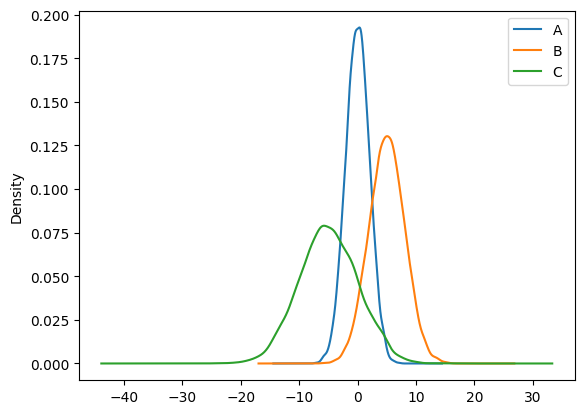

In [3]:
df.plot.kde()

**👀 What to look at:** three bells at **different x-positions** with **different widths** — `A` sits near 0 (narrow), `B` near 5, `C` near −5 and spread widest. This is the problem in one picture: a distance-based model (KNN, SVM, gradient descent) would treat `C` as "more important" purely because its numbers are bigger.

---

## 📏 Concept 1 — Scaling

### 🎬 How we got here
We just saw three columns that can't be compared fairly.

### 😖 The problem
Models that compare magnitudes get biased toward whichever feature has the biggest raw numbers — not the most *informative* one, just the biggest.

### 💡 The idea
Rescale every column to a common ruler **without changing its shape**. Like converting all latencies to ms before comparing SLAs. *Where the analogy breaks:* unit conversion is lossless; some scalers distort distances when outliers exist.

### 🔍 What this actually is
Three scalers, three rulers:

$$z=\frac{x-\mu}{\sigma} \qquad \hat{x}=\frac{x-x_{min}}{x_{max}-x_{min}} \qquad \tilde{x}=\frac{x-Q_2}{Q_3-Q_1}$$

- $x$ = one raw value; $\mu,\sigma$ = column mean & std; $x_{min},x_{max}$ = column extremes; $Q_2$ = median, $Q_1,Q_3$ = 25th/75th percentiles.
- **StandardScaler** → mean 0, std 1. **MinMax** → squeezed into $[0,1]$. **Robust** → centred on the median, scaled by the middle-50% so outliers can't hijack it.

**The pattern every sklearn transformer follows:** `scaler = StandardScaler()` → `scaler.fit_transform(df)`.

- `fit` = learn the column statistics ($\mu,\sigma$).
- `transform` = apply the formula.
- `fit_transform` = both at once.

In production you'd `fit` on **train only** and `transform` test — fitting on test leaks information. **Note:** `fit_transform` returns a plain `ndarray` (no column names), so the next cell re-wraps it in a DataFrame.

In [4]:
scaler = StandardScaler()

In [5]:
scaled = scaler.fit_transform(df)

In [6]:
df = pd.DataFrame(scaled, columns=['A','B','C'])

**📖 Read the output:** the KDE after StandardScaler — all three bells now sit at **centre 0** with **width 1**, perfectly overlapped. Shapes are unchanged (still bells); only position and spread moved.

> ⚠️ **A real bug in the next two scalers.** Look at the code: `MinMaxScaler` is fit on `df` — but `df` was *just overwritten* with the StandardScaled values. Then `RobustScaler` is fit on the MinMax output. So those two plots show **cumulative** transforms, not raw→scaled. Harmless on this clean data, but the honest pattern is: keep the raw frame untouched and fit each scaler on it separately. I'll run them correctly right after your original cells so you can compare.

<Axes: ylabel='Density'>

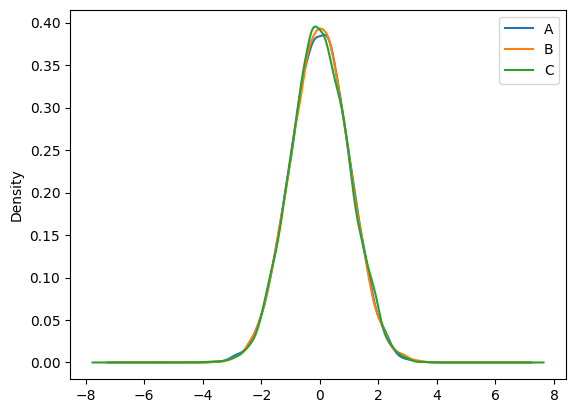

In [7]:
df.plot.kde()

In [8]:
minmax = MinMaxScaler()
mm_scaled = minmax.fit_transform(df)

<Axes: ylabel='Density'>

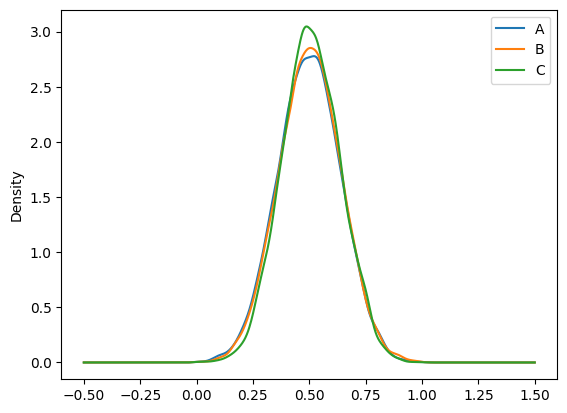

In [9]:
df = pd.DataFrame(mm_scaled,columns=['A','B','C'])
df.plot.kde()

In [10]:
rscaler = RobustScaler()

In [11]:
robust = rscaler.fit_transform(df)
df = pd.DataFrame(robust, columns=['A','B','C'])

<Axes: ylabel='Density'>

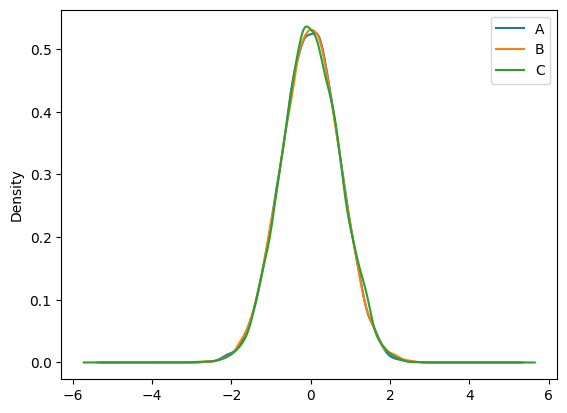

In [12]:
df.plot.kde()

**📖 Read the three plots above.** Because of the chaining bug, plot 3 (MinMax) and plot 4 (Robust) are transforms-of-transforms. Below is the **correct** version — each scaler fit on the *raw* data, drawn side by side so the difference is actually visible. This time we inject **one outlier** into column `C` so you can watch each scaler react.

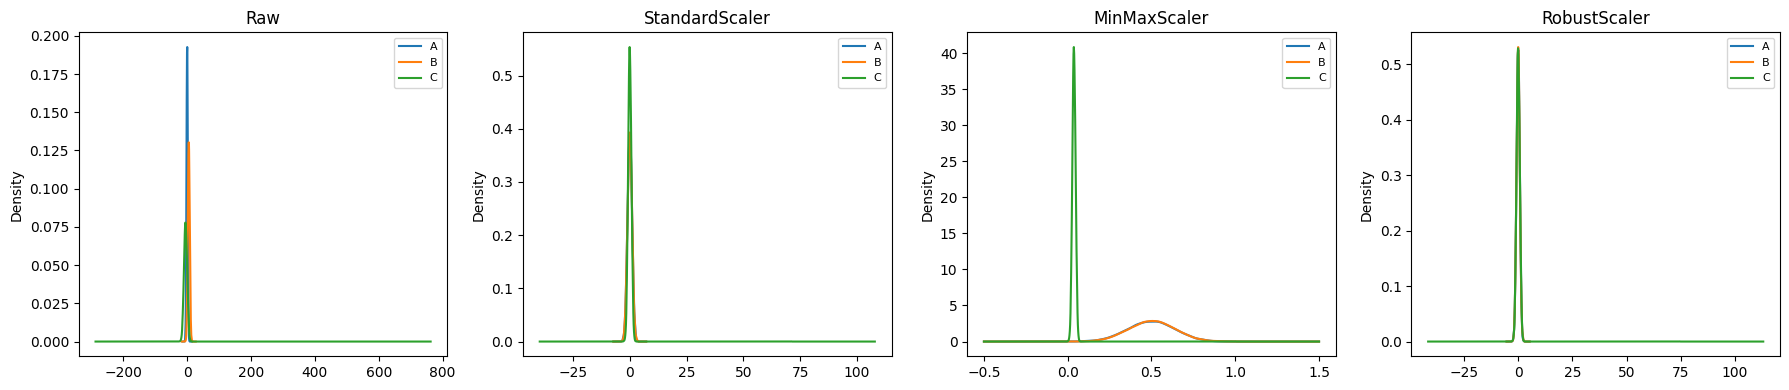

In [33]:
# Rebuild the RAW data (same seed -> identical values), then add ONE outlier to column C.
np.random.seed(5)
df_raw = pd.DataFrame({
    'A': np.random.normal(0, 2, 10000),
    'B': np.random.normal(5, 3, 10000),
    'C': np.random.normal(-5, 5, 10000),
})
df_raw.loc[0, 'C'] = 500          # a single wild sensor spike

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

df_raw.plot.kde(ax=axes[0], title='Raw')
pd.DataFrame(StandardScaler().fit_transform(df_raw), columns=['A','B','C']).plot.kde(ax=axes[1], title='StandardScaler')
pd.DataFrame(MinMaxScaler().fit_transform(df_raw), columns=['A','B','C']).plot.kde(ax=axes[2], title='MinMaxScaler')
pd.DataFrame(RobustScaler().fit_transform(df_raw), columns=['A','B','C']).plot.kde(ax=axes[3], title='RobustScaler')

for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**👀 What to look at.** Watch column `C` across the four panels. **StandardScaler**: the single 500 spike stretches the x-axis so far the bell flattens — the outlier redefined the scale. **MinMaxScaler**: the spike pins `C`'s max to 1.0 and crushes every normal point into a sliver near 0 — the most fragile. **RobustScaler**: `C`'s bell keeps its shape; the spike is pushed to the edge but can't distort the centre. That is the whole trade: mean/std and min/max trust the extremes, the median/IQR don't.

> ✅ **Checkpoint.** (1) One feature has a huge outlier — which scaler keeps the rest of the data readable? (2) Why would you still *not* use RobustScaler if your model assumes standard-normal inputs?
> **Answers:** (1) RobustScaler — median/IQR ignore the spike. (2) Because RobustScaler output is not mean-0/std-1; algorithms tuned for that assumption (e.g. some regularised linear models) behave differently.

---

## 🔲 Concept 2 — Binarizer

### 🎬 How we got here
Scaling kept the numbers continuous. Sometimes we don't want continuous at all — we want a yes/no flag.

### 😖 The problem
A fraud score of 0.51 vs 0.99 shouldn't both count as "maybe". We want a hard line: **flag or don't flag**.

### 💡 The idea
A smoke alarm. Above the threshold it screams (1), below it's silent (0). All magnitude information above the line is thrown away — 0.51 and 0.99 both just beep. *Where the analogy breaks:* a real alarm has hysteresis (it stops below a lower threshold); `Binarizer` has a single hard edge.

### 🔍 What this actually is
$$B(x)=\begin{cases}1 & x > t \\ 0 & x \le t\end{cases}$$

Note the **strict** inequality: a value exactly equal to `t` maps to 0. With `threshold=5`, the value `5` itself becomes 0.

In [13]:
binary = Binarizer(threshold=5)

a = np.array([[ 30, 10,  22],
              [ 20,  2,  10],
              [ 33,  5, 5]])

binary1 = binary.transform(a)
binary1

array([[1, 1, 1],
       [1, 0, 1],
       [1, 0, 0]])

**📖 Read the output.** Input rows `[30,10,22]`, `[20,2,10]`, `[33,5,5]` with `threshold=5` → `[[1,1,1],[1,0,1],[1,0,0]]`. Look at the two `5`s — both became **0** because the rule is *strictly greater than*. And `22` vs `33` are both just `1`; the size above the line is gone.

---

## 📐 Concept 3 — Normalizer

### 🎬 How we got here
Every scaler so far worked **down a column**. The next three cells do the opposite — across a **row**.

### 😖 The problem
Two customers: one bought `[5,2,3]` items, another `[50,20,30]`. Same shopping *pattern* (5:2:3), wildly different totals. Column scaling can't fix that — the difference is per-row magnitude, not per-column spread.

### 💡 The idea
Compare the *recipe*, not the *portion size*. Divide each row by its own length so every row becomes a unit vector — direction kept, size erased. Like normalising API error counts per service to a percentage before comparing reliability. *Breaks:* if absolute magnitude is the signal (a big customer *is* different), normalizing destroys real information.

### 🔍 What this actually is
Each row $\mathbf{x}$ is divided by its L2 norm:

$$\text{L2}(\mathbf{x})=\sqrt{x_1^2+x_2^2+\dots+x_n^2}, \qquad \hat{\mathbf{x}}=\frac{\mathbf{x}}{\text{L2}(\mathbf{x})}$$

Row $[5,2,3]$: $\sqrt{25+4+9}=\sqrt{38}\approx6.164$ → $[0.811,\ 0.324,\ 0.487]$. The next cells compute this **by hand**, then verify `sklearn.Normalizer` gives the identical array.

In [14]:
X = [[5, 2, 3],
     [2, 4, 10],
     [6, 8, 6]]

sss = [np.sqrt(np.sum(np.power(X[i], 2))) for i in range(len(X))]

In [4]:
len(X)

3

In [15]:
np.array([X[k] / sss[k] for k in range(len(X))])

array([[0.81110711, 0.32444284, 0.48666426],
       [0.18257419, 0.36514837, 0.91287093],
       [0.51449576, 0.68599434, 0.51449576]])

In [16]:
normalizer = Normalizer()
data_tf = normalizer.fit_transform(X)

In [17]:
data_tf

array([[0.81110711, 0.32444284, 0.48666426],
       [0.18257419, 0.36514837, 0.91287093],
       [0.51449576, 0.68599434, 0.51449576]])

**📖 Read the output.** The two arrays are **identical** — the hand-rolled list comprehension and `sklearn.Normalizer()` both give `[0.811, 0.324, 0.487], [0.183, 0.365, 0.913], [0.514, 0.686, 0.514]`. That's the "make it click" moment: the library is doing exactly the $\sqrt{\sum x_i^2}$ division we did by hand.

---

## 🏷️ Concept 4 — Encoders (categorical → numbers)

### 🎬 How we got here
So far everything was already numeric. Real data has *text* — team names, sizes, cities — and models only understand numbers.

### 😖 The problem
A column like `TEAM = [RCB, CSK, MI, RCB]` is meaningless to a linear model. We must convert it. **How** we convert changes what the model learns.

### 💡 The idea
Three ways to assign numbers, each encoding a different *assumption* about the categories:

| Encoder | Idea | Assumes | Watch out |
|---|---|---|---|
| `LabelEncoder` | one integer per label | — | invents a fake order (0<1<2) — **targets only, not features** |
| `OneHotEncoder` | one 0/1 column per label | no order | blows up column count; sparse |
| `OrdinalEncoder` | integer by *your* rank | real order exists | you must supply the correct order |

### 🔍 What this actually is
- **Label** → `CSK=0, MI=1, RCB=2` (alphabetical). Fine for `y`, dangerous for `X`.
- **One-Hot** → three columns `CSK, MI, RCB`, one `1` per row. No fake order.
- **Ordinal** → `Small=0, Medium=1, Large=2` — *you* declare the order via `categories=`.

> ⚠️ **Heads-up:** the next five cells read `/Users/shridharmankar/encoding.csv` — a path from the original author's laptop. It throws `FileNotFoundError` here. After them I'll drop in a generated `TEAM` DataFrame so `LabelEncoder` and `OneHotEncoder` actually run for you.

In [18]:
dff = pd.read_csv("/Users/shridharmankar/encoding.csv")
dff

FileNotFoundError: [Errno 2] No such file or directory: '/Users/shridharmankar/encoding.csv'

In [25]:
le = LabelEncoder()
df1 = dff
df1.TEAM = le.fit_transform(df1.TEAM)
df1

,TEAM,YEAR
0,0,2000
1,1,2002
2,2,2003
3,3,2004
4,0,2005
5,2,2006
6,1,2007
7,0,2008
8,3,2009


In [26]:
enc = OneHotEncoder()
enc_df1 = pd.DataFrame(enc.fit_transform(df1[['TEAM']]).toarray())
enc_df1

,0,1,2,3
0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0
5,0.0,0.0,1.0,0.0
6,0.0,1.0,0.0,0.0
7,1.0,0.0,0.0,0.0
8,0.0,0.0,0.0,1.0


In [27]:
abc = df1.join(enc_df1)
abc

,TEAM,YEAR,0,1,2,3
0,0,2000,1.0,0.0,0.0,0.0
1,1,2002,0.0,1.0,0.0,0.0
2,2,2003,0.0,0.0,1.0,0.0
3,3,2004,0.0,0.0,0.0,1.0
4,0,2005,1.0,0.0,0.0,0.0
5,2,2006,0.0,0.0,1.0,0.0
6,1,2007,0.0,1.0,0.0,0.0
7,0,2008,1.0,0.0,0.0,0.0
8,3,2009,0.0,0.0,0.0,1.0


In [28]:
final = abc.drop(['TEAM'], axis='columns')
final

,YEAR,0,1,2,3
0,2000,1.0,0.0,0.0,0.0
1,2002,0.0,1.0,0.0,0.0
2,2003,0.0,0.0,1.0,0.0
3,2004,0.0,0.0,0.0,1.0
4,2005,1.0,0.0,0.0,0.0
5,2006,0.0,0.0,1.0,0.0
6,2007,0.0,1.0,0.0,0.0
7,2008,1.0,0.0,0.0,0.0
8,2009,0.0,0.0,0.0,1.0


**The cells above were the author's originals** — they need the missing CSV, so they're for reading only. Here is the **runnable version** with a tiny generated `TEAM` column doing the exact same three steps: Label → One-Hot → drop the original.

In [34]:
# A stand-in for the missing encoding.csv: a TEAM column + a numeric feature.
dff = pd.DataFrame({
    'TEAM':  ['RCB', 'CSK', 'MI', 'RCB', 'MI', 'CSK'],
    'SCORE': [180,  150,  200,  175,  210,  160],
})

# --- LabelEncoder: one integer per team (alphabetical: CSK=0, MI=1, RCB=2) ---
le = LabelEncoder()
dff['TEAM_label'] = le.fit_transform(dff['TEAM'])

# --- OneHotEncoder: one 0/1 column per team, no fake order ---
# sparse_output=False -> return a normal dense array (not a sparse matrix).
enc = OneHotEncoder(sparse_output=False)
onehot = pd.DataFrame(
    enc.fit_transform(dff[['TEAM']]),          # shape: (6 rows, 3 team-columns)
    columns=enc.get_feature_names_out(['TEAM']) # -> ['TEAM_CSK','TEAM_MI','TEAM_RCB']
)

final = dff.join(onehot).drop(['TEAM'], axis='columns')
print("LabelEncoded (note the invented order):")
print(dff[['TEAM', 'TEAM_label']])
print("\nOne-Hot final (no order, 3 extra columns):")
print(final)

LabelEncoded (note the invented order):
  TEAM  TEAM_label
0  RCB           2
1  CSK           0
2   MI           1
3  RCB           2
4   MI           1
5  CSK           0

One-Hot final (no order, 3 extra columns):
   SCORE  TEAM_label  TEAM_CSK  TEAM_MI  TEAM_RCB
0    180           2       0.0      0.0       1.0
1    150           0       1.0      0.0       0.0
2    200           1       0.0      1.0       0.0
3    175           2       0.0      0.0       1.0
4    210           1       0.0      1.0       0.0
5    160           0       1.0      0.0       0.0


**📖 Read the output.** Label encoding turned `RCB→2, CSK→0, MI→1` — alphabetical, and now a model thinks `RCB(2)` is "twice" `MI(1)`. That's the trap. The One-Hot block replaces the single label with three 0/1 columns — row 0 is `TEAM_RCB=1`, others 0 — no order implied, at the cost of extra width.

**👀 On `OrdinalEncoder` (next cell):** it encodes `Small=0, Medium=1, Large=2` because **you** passed `categories=[["Small","Medium","Large"]]`. Remove that argument and it would sort alphabetically → `Large=0, Medium=1, Small=2` (backwards!). For genuinely-ordered data, always declare the order.

> ✅ **Checkpoint.** (1) When is `LabelEncoder` acceptable on a feature? (2) Why is One-Hot safer than Label for `TEAM`?
> **Answers:** (1) Almost never — only if the categories truly have no order *and* you accept the model treating integers as ordered; prefer One-Hot. (2) One-Hot gives each team an independent axis, so no false "RCB > MI" ordering leaks into the model.

In [19]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

df = pd.DataFrame({"Size": ["Small", "Medium", "Large", "Small", "Large"]})

encoder = OrdinalEncoder(categories=[["Small", "Medium", "Large"]])

df["Size_Encoded"] = encoder.fit_transform(df[["Size"]])

print(df)

     Size  Size_Encoded
0   Small           0.0
1  Medium           1.0
2   Large           2.0
3   Small           0.0
4   Large           2.0


**📖 Read the output:** `Small=0, Medium=1, Large=2` — exactly the order we declared.

---

## ⚖️ Concept 5 — Class imbalance

### 🎬 How we got here
Features are clean and encoded. Now the *target* `y` has a problem: `[Fail, Fail, Fail, Pass, Pass]` — 3 vs 2, and in real fraud/churn data it's more like 98 vs 2.

### 😖 The problem
A lazy model that *always* predicts the majority class scores 98% accuracy while catching zero minority cases. Accuracy lies when classes are lopsided.

### 💡 The idea
Rebalance the training set so the model sees both classes fairly — either **photocopy** the rare class (over-sampling) or **shred** some of the common class (under-sampling). Backend analogy: load-balancing test traffic so a rare error path actually gets exercised. *Breaks:* photocopying duplicates information (overfitting risk); shredding throws real data away.

### 🔍 What this actually is
- `RandomOverSampler` — duplicates random minority rows until balanced. 5 rows → 6.
- `RandomUnderSampler` — drops random majority rows until balanced. 5 rows → 4.

Both need `imbalanced-learn` (installed by the `pip` cell). **Production rule:** resample the **training split only**, never before the train/test split — otherwise duplicated rows leak into test and inflate your metrics.

In [21]:
pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]
Note: you may need to restart the kernel to use updated packages.


In [22]:
from imblearn.over_sampling import RandomOverSampler

X = pd.DataFrame({"Marks": [10, 20, 30, 40, 50]})
y = ["Fail", "Fail", "Fail", "Pass", "Pass"]

ros = RandomOverSampler()

X_resampled, y_resampled = ros.fit_resample(X, y)

print(y_resampled)

['Fail', 'Fail', 'Fail', 'Pass', 'Pass', 'Pass']


In [23]:
from imblearn.under_sampling import RandomUnderSampler

X = pd.DataFrame({"Marks": [10, 20, 30, 40, 50]})
y = ["Fail", "Fail", "Fail", "Pass", "Pass"]

rus = RandomUnderSampler()

X_resampled, y_resampled = rus.fit_resample(X, y)

print(y_resampled)

['Fail', 'Fail', 'Pass', 'Pass']


**📖 Read the two outputs.** Over-sampler: `[Fail×3, Pass×3]` — it **copied** one `Pass` row (5→6). Under-sampler: `[Fail×2, Pass×2]` — it **deleted** one `Fail` row (5→4). Both end balanced; one risks overfitting, the other loses data.

> 🔀 **Your call.** Your real dataset is 98/2 imbalanced. Three options: **(a)** over-sample the minority, **(b)** under-sample the majority, **(c)** leave it and switch to a better metric (precision/recall, AUC) or use `class_weight`.
> **Trade-off:** (a) keeps all data but can overfit the copied rows; (b) is fast but discards information; (c) is usually the first thing to try in production — no data touched, the model or the metric just stops rewarding the majority class.

---

## 🕳️ Concept 6 — Missing values

### 🎬 How we got here
Classes are balanced. But the data has holes: `Age = [20, 25, None, 30, 35]` — most estimators refuse to run with a `NaN` inside.

### 😖 The problem
You can't average a blank. Either **fill** the hole with a sensible guess (imputation) or **delete** the row — and each choice biases the data differently.

### 💡 The idea
Filling is like estimating a missing latency sample from its neighbours; deleting is like dropping the log line entirely. Fill keeps rows but can blur the truth; delete is honest but shrinks your data.

### 🔍 What the three imputers actually do

- **`SimpleImputer(strategy="mean")`** → fill with the column average.
- **`SimpleImputer(strategy="median")`** → fill with the middle value; robust to outliers.
- **`KNNImputer(n_neighbors=k)`** → find the `k` most similar rows (using the *other* columns) and average them.

On `Age = [20, 25, _, 30, 35]`: mean = median = **27.5** here only because the data is symmetric — add an outlier like `120` and mean fills `~49` while median stays `27.5`. That's when the choice starts to matter. The next four cells run mean, median, KNN, then the deletion fallbacks (`dropna`, `drop_duplicates`).

In [24]:
from sklearn.impute import SimpleImputer

df = pd.DataFrame({"Age": [20, 25, None, 30, 35]})

imputer = SimpleImputer(strategy="mean")

df["Age"] = imputer.fit_transform(df[["Age"]])
print(df)

    Age
0  20.0
1  25.0
2  27.5
3  30.0
4  35.0


In [25]:
from sklearn.impute import SimpleImputer

df = pd.DataFrame({"Age": [20, 25, None, 30, 35]})

imputer = SimpleImputer(strategy="median")

df["Age"] = imputer.fit_transform(df[["Age"]])
print(df)

    Age
0  20.0
1  25.0
2  27.5
3  30.0
4  35.0


In [26]:
from sklearn.impute import KNNImputer

df = pd.DataFrame({"Height": [170, 172, 171, 180], "Weight": [65, 67, None, 85]})

imputer = KNNImputer(n_neighbors=2)

df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print("After Imputation")
print(df)

After Imputation
   Height  Weight
0   170.0    65.0
1   172.0    67.0
2   171.0    66.0
3   180.0    85.0


In [27]:
df = pd.DataFrame({"Age": [20, 25, None, 30, 35]})

df = df.dropna()
print(df)

    Age
0  20.0
1  25.0
3  30.0
4  35.0


In [28]:
df = pd.DataFrame({"Name": ["Ram", "Shyam", "Ram", "Amit"]})

df = df.drop_duplicates()
print(df)

    Name
0    Ram
1  Shyam
3   Amit


**📖 Read the four outputs.**
- **Mean & median** both filled `27.5` — identical only because `[20,25,30,35]` is symmetric.
- **KNNImputer** filled the missing `Weight` with **66.0** = average of the two nearest rows by `Height` ((65+67)/2). It used *another column* to guess, not just the column average.
- **`dropna()`** deleted the whole row (5→4); **`drop_duplicates()`** removed the repeated `Ram` (4→3). Deletion is honest but irreversible — fine only when holes are rare and random.

---

## 🛠️ Concept 7 — Feature engineering (4 quick moves)

### 🎬 How we got here
Data is scaled, encoded, balanced, and hole-free. The last lever: **create better columns** from the ones we have.

### 😖 The problem
Sometimes the signal isn't in any single column — it's in a *transformation* (`log`), a *combination* (`length×width`), a *bucket* (age-group), or a *part* of a value (month-of-year).

### 💡 The idea
Help the model by hand-crafting features it can't easily derive linearly. Like a backend dev adding a derived `p99_latency` column instead of making the dashboard recompute it. *Breaks:* engineered features can leak target information or add noise — validate each one.

### 🔍 The four moves
1. **Log transform** — `np.log(Salary)` compresses 10,000→100,000 into 9.2→11.5. Every 10× jump becomes a constant +2.3 step. For money/population skew. (Fails on 0/negatives → use `np.log1p`.)
2. **Interaction** — `Area = Length × Width`. New signal from two columns.
3. **Binning** — `KBinsDiscretizer(n_bins=3, strategy="uniform")` cuts age 18–60 into equal-width buckets `[0,0,1,1,2]`.
4. **Date parts** — `pd.to_datetime` + `.dt.year/.month/.day` decompresses one opaque string into usable numbers.

In [29]:
import pandas as pd
import numpy as np

df = pd.DataFrame({"Salary": [10000, 20000, 50000, 100000]})

df["Log_Salary"] = np.log(df["Salary"])
print(df)

   Salary  Log_Salary
0   10000    9.210340
1   20000    9.903488
2   50000   10.819778
3  100000   11.512925


In [30]:
import pandas as pd

df = pd.DataFrame({"Length": [2, 3, 4], "Width": [5, 6, 7]})

df["Area"] = df["Length"] * df["Width"]
print(df)

   Length  Width  Area
0       2      5    10
1       3      6    18
2       4      7    28


In [31]:
from sklearn.preprocessing import KBinsDiscretizer

df = pd.DataFrame({"Age": [18, 25, 35, 45, 60]})

encoder = KBinsDiscretizer(n_bins=3, encode="ordinal", strategy="uniform")

df["Age_Bin"] = encoder.fit_transform(df[["Age"]])
print(df)

   Age  Age_Bin
0   18      0.0
1   25      0.0
2   35      1.0
3   45      1.0
4   60      2.0


In [32]:
df = pd.DataFrame({"Date": ["2025-01-10", "2025-02-15", "2025-03-20"]})

df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
print(df)

        Date  Year  Month  Day
0 2025-01-10  2025      1   10
1 2025-02-15  2025      2   15
2 2025-03-20  2025      3   20


**📖 Read the four outputs.** Log: `10000→9.21`, `100000→11.51` — a 10× salary jump is now a flat +2.3. Interaction: `2×5=10, 3×6=18, 4×7=28`. Binning: ages `[18,25,35,45,60]` → bins `[0,0,1,1,2]`. Dates: `2025-01-10` → `Year=2025, Month=1, Day=10`.

---

## 🎯 What We Learned

- **Scaling** re-units columns without reshaping them; pick by outlier-sensitivity (Standard / MinMax / Robust).
- **Binarizer** hard-thresholds to 0/1 and throws away magnitude.
- **Normalizer** scales *rows* to unit length — for comparing patterns, not totals.
- **Encoders** turn categories into numbers; the choice encodes an assumption about order.
- **Resampling** balances classes — on the training split only.
- **Imputation** fills holes; mean/median per column, KNN across columns; deletion is the honest fallback.
- **Feature engineering** builds columns the model can't derive itself.

### 🧾 Cheat-sheet

| Tool | Axis | Use when | Avoid when |
|---|---|---|---|
| StandardScaler | column | roughly normal data | heavy outliers |
| MinMaxScaler | column | you need a fixed [0,1] range | any extreme value exists |
| RobustScaler | column | outliers present | model needs mean-0/std-1 |
| Binarizer | element | you want a yes/no flag | magnitude matters |
| Normalizer | row | comparing row *patterns* | row totals are the signal |
| LabelEncoder | target only | encoding `y` | encoding `X` |
| OneHotEncoder | feature | no category order | very high cardinality |
| OrdinalEncoder | feature | real order, you supply it | order is wrong |
| Over/UnderSampler | rows | imbalanced train split | before the split |
| SimpleImputer | column | few random holes | holes are informative |
| KNNImputer | row (via cols) | rows are similar | wide/noisy data |

### ⚠️ When this breaks
- Fitting any transformer on the **full** dataset (train+test) leaks information — fit on train only.
- One-Hot on a 10,000-category column explodes memory.
- Imputing with mean when the data is skewed pulls every fill toward the outliers.

### 🚀 Where to go next
The natural next step: bundle these steps into a `Pipeline` / `ColumnTransformer` so `fit`-on-train-only happens automatically — that's the production-grade version of everything we did by hand today.